In [ ]:
%pip install arm-pyart s3fs

In [24]:
import gzip, io
import fsspec, pyart
import matplotlib.pyplot as plt

# --- 1. connect to the public NEXRAD archive (anonymous) ---
fs = fsspec.filesystem("s3", anon=True)
folder = "unidata-nexrad-level2/2006/03/11/KNKX/"

# --- 2. (optional) browse the folder to pick a ~05 UTC volume ---
for f in fs.ls(folder):
    print(f.split("/")[-1])


KNKX20060311_000025.gz
KNKX20060311_000544.gz
KNKX20060311_001001.gz
KNKX20060311_001418.gz
KNKX20060311_001835.gz
KNKX20060311_002252.gz
KNKX20060311_002709.gz
KNKX20060311_003126.gz
KNKX20060311_003544.gz
KNKX20060311_004000.gz
KNKX20060311_004417.gz
KNKX20060311_004835.gz
KNKX20060311_005251.gz
KNKX20060311_005708.gz
KNKX20060311_010126.gz
KNKX20060311_010543.gz
KNKX20060311_011000.gz
KNKX20060311_011417.gz
KNKX20060311_011834.gz
KNKX20060311_012251.gz
KNKX20060311_012709.gz
KNKX20060311_013125.gz
KNKX20060311_013543.gz
KNKX20060311_014000.gz
KNKX20060311_014417.gz
KNKX20060311_014834.gz
KNKX20060311_015251.gz
KNKX20060311_015709.gz
KNKX20060311_020126.gz
KNKX20060311_020542.gz
KNKX20060311_020959.gz
KNKX20060311_021416.gz
KNKX20060311_021834.gz
KNKX20060311_022251.gz
KNKX20060311_022708.gz
KNKX20060311_023125.gz
KNKX20060311_023542.gz
KNKX20060311_023959.gz
KNKX20060311_024417.gz
KNKX20060311_024833.gz
KNKX20060311_025251.gz
KNKX20060311_025708.gz
KNKX20060311_030124.gz
KNKX2006031

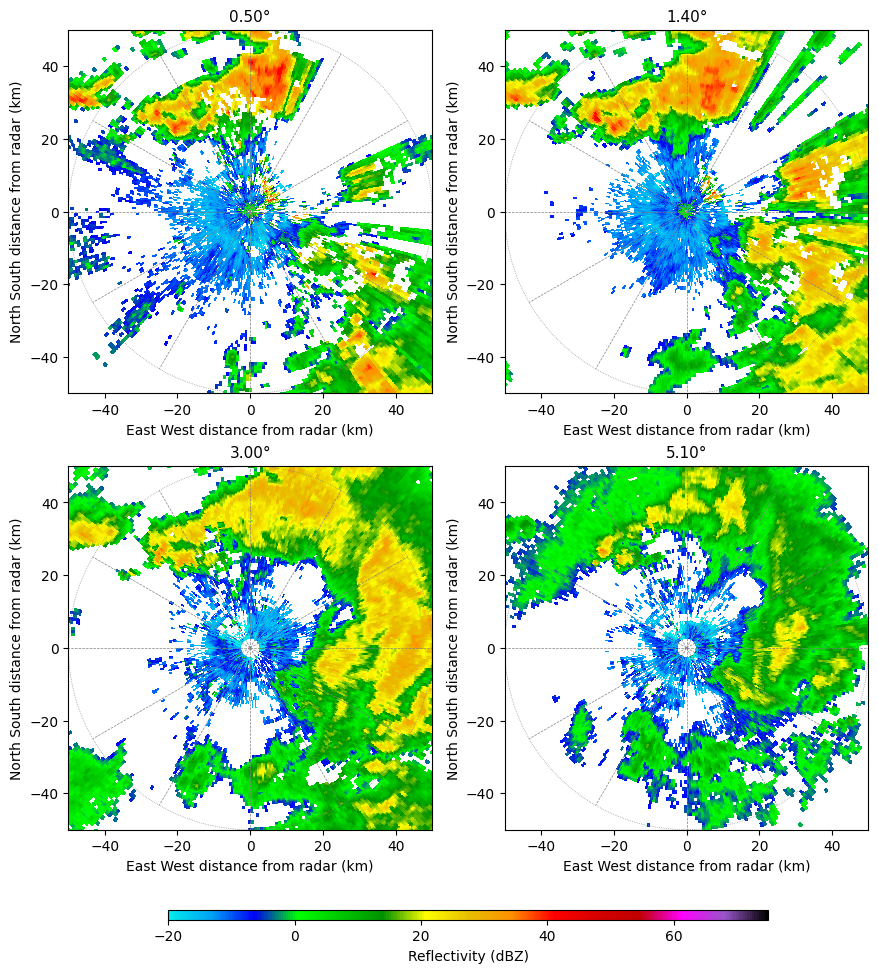

In [37]:
import numpy as np

# --- read radar ---
key = folder + "KNKX20060311_222506.gz"

with fs.open(key, "rb") as fh:
    raw = fh.read()

if raw[:2] == b"\x1f\x8b":
    raw = gzip.decompress(raw)

radar = pyart.io.read_nexrad_archive(io.BytesIO(raw))

# --- figure setup (more compact) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

disp = pyart.graph.RadarDisplay(radar)
max_range = 50
sweeps = 0, 4, 8, 10

for i in range(4):
    ax = axes[i]
    plt.sca(ax)

    disp.plot(
        "reflectivity",
        sweep=sweeps[i],
        vmin=-20,
        vmax=75,
        cmap="NWSRef",
        colorbar_flag=False
    )

    disp.set_limits(xlim=(-max_range, max_range),
                    ylim=(-max_range, max_range))

    # range rings
    disp.plot_range_rings(
        [50, 100, 150, 200, 250, 300, 350, 400],
        col="gray", lw=0.5, ls="dotted"
    )

    # azimuth spokes
    for az in range(0, 360, 30):
        theta = np.deg2rad(az)
        x = [0, max_range * np.sin(theta)]
        y = [0, max_range * np.cos(theta)]
        ax.plot(x, y, color="gray", lw=0.5, ls="dashed")

    # title
    angle = radar.fixed_angle["data"][sweeps[i]]
    ax.set_title(f"{angle:.2f}°", fontsize=11)

# --- MANUAL spacing (prevents overlap) ---
plt.subplots_adjust(
    left=0.1, right=0.9,
    top=0.9, bottom=0.1,
    wspace=0.2, hspace=0.2
)

# --- dedicated colorbar axis (below plots) ---
cax = fig.add_axes([0.2, 0.01, 0.6, 0.01])  # [left, bottom, width, height]

cbar = plt.colorbar(disp.plots[0], cax=cax, orientation="horizontal")
cbar.set_label("Reflectivity (dBZ)")

plt.savefig("ksox_4panel_clean.png", dpi=130)
plt.show()

